<div style="background-color: silver; padding: 20px; text-align: center; border-radius: 10px;">
    <h1 style="color: black; font-weight: bold;">
        &#8226;&#8226;
        <span style="color: black;"> Laptop Price Prediction </span> <span style="color: white;">-</span> <span style="color: black">Regression </span>
        &#8226;&#8226;
    </h1>
</div>

Bu proje, makine öğrenimi tekniklerini kullanarak dizüstü bilgisayar fiyatlarını tahmin etmeye odaklanmaktadır. Bir takım özellikleri içeren bir veri setini analiz edeceğiz. Regresyon algoritmalarını uygulayarak, bu özelliklere dayalı olarak laptop fiyatlarını doğru bir şekilde tahmin eden bir model geliştirmeyi hedefliyoruz. Bu, tüketicilerin bilinçli satın alma kararları vermesine ve üreticilerin rekabetçi fiyatlar belirlemesine yardımcı olacaktır.
______
This project focuses on predicting laptop prices using machine learning techniques. We will analyze a dataset containing various specifications. By applying regression algorithms, we aim to develop a model that accurately predicts laptop prices based on these features. This will help consumers make informed purchasing decisions and assist manufacturers in setting competitive prices.

**Data Dictionary**

| Column Name        | Description                                | Turkish Translation         |
|--------------------|--------------------------------------------|-----------------------------|
| Company             | Name of the laptop manufacturer             | Şirket                      |
| TypeName           | Type of the laptop (e.g., Ultrabook)     | Laptop Türü                 |
| Inches             | Screen size in inches                      | Ekran Boyutu (inç)         |
| ScreenResolution    | Display resolution (e.g., 1920x1080)      | Ekran Çözünürlüğü          |
| Cpu                | Processor specifications                    | İşlemci                     |
| Ram                | Amount of RAM                              | RAM Miktarı                 |
| Memory             | Storage type and capacity                  | Bellek                      |
| Gpu                | Graphics processing unit                    | Grafik Kartı                |
| OpSys              | Operating system (e.g., Windows, macOS)   | İşletim Sistemi             |
| Weight             | Weight of the laptop                       | Ağırlık                     |
| Price              | Price of the laptop                        | Fiyat                       |

<img src='https://i.computer-bild.de/imgs/5/1/2/3/1/8/8/cb425e04c8dd9848.jpg'>
<a href='https://classroom.google.com/c/NzIwMjcyMjkxMjgy/a/NzIwMjcyMjkxNDUw/details' target=_blank>
Click here for the dataset </a>

**Import libary**

In [2]:
import pandas as pd
pd.set_option("display.max_columns",55)
#pd.set_option("display.max_rows",None)

import warnings
warnings.filterwarnings("ignore")

In [284]:
df=pd.read_csv('laptop_data.csv')

**Exploratory Data Analysis**

In [5]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [6]:
df.shape

(1303, 12)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [11]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

**Data Visualization**

In [17]:
import seaborn as sns

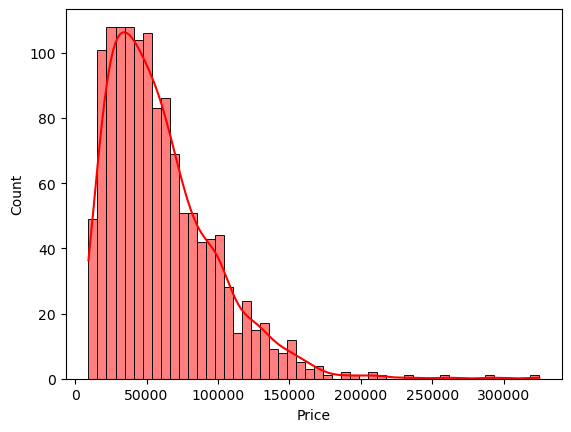

In [18]:
sns.histplot(x=df['Price'],kde=True,color='red',bins=50); 

In [105]:
df['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

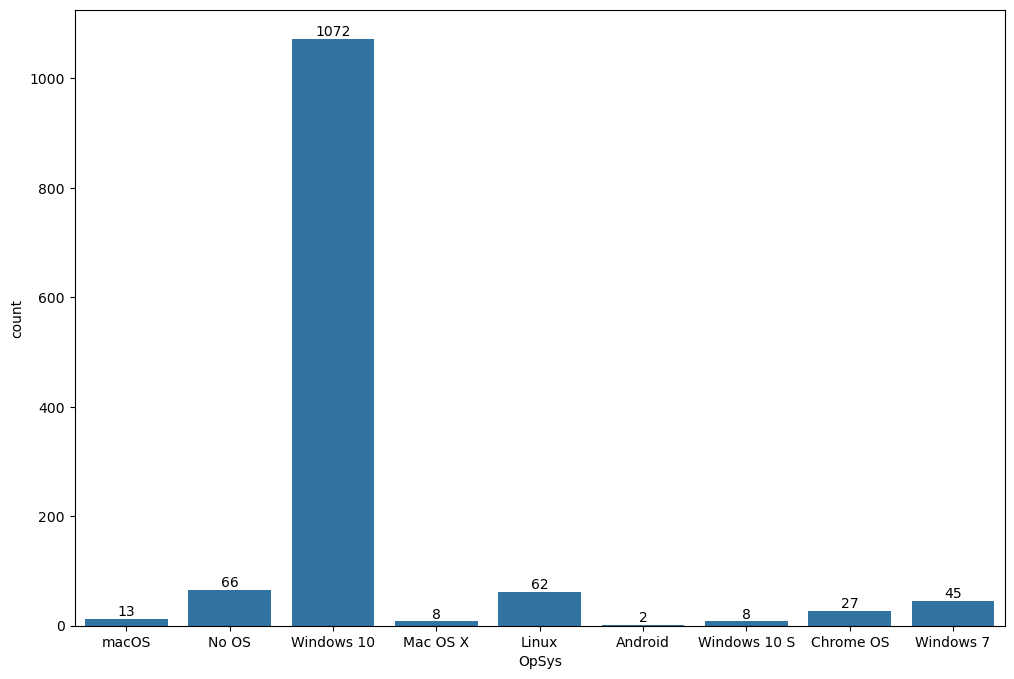

In [135]:
plt.figure(figsize=(12,8))
ax=sns.countplot(x=df['OpSys'])
ax.bar_label(ax.containers[0]);

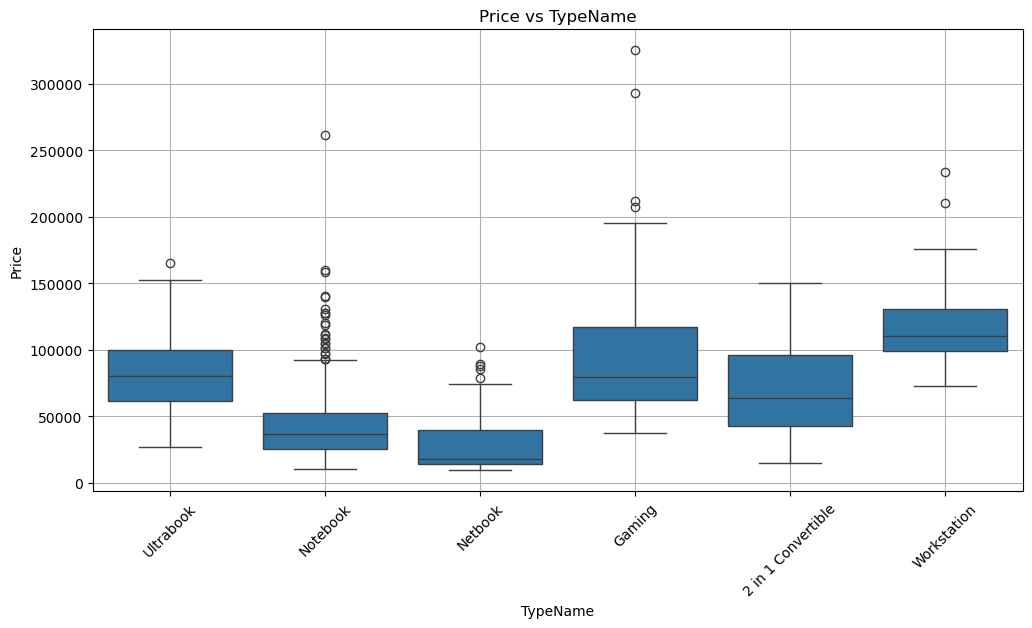

In [137]:
# Boxplot for TypeName
plt.figure(figsize=(12, 6))
sns.boxplot(x='TypeName', y='Price', data=df)
plt.title('Price vs TypeName')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [ ]:
# ? TouchScreen Laptoplar daha fiyatli ve özellikleri artinca fiyatida artiyor.
# Ama TouchScreen olan gücü digerlerine göre daha düsüktür tavsiye etmem

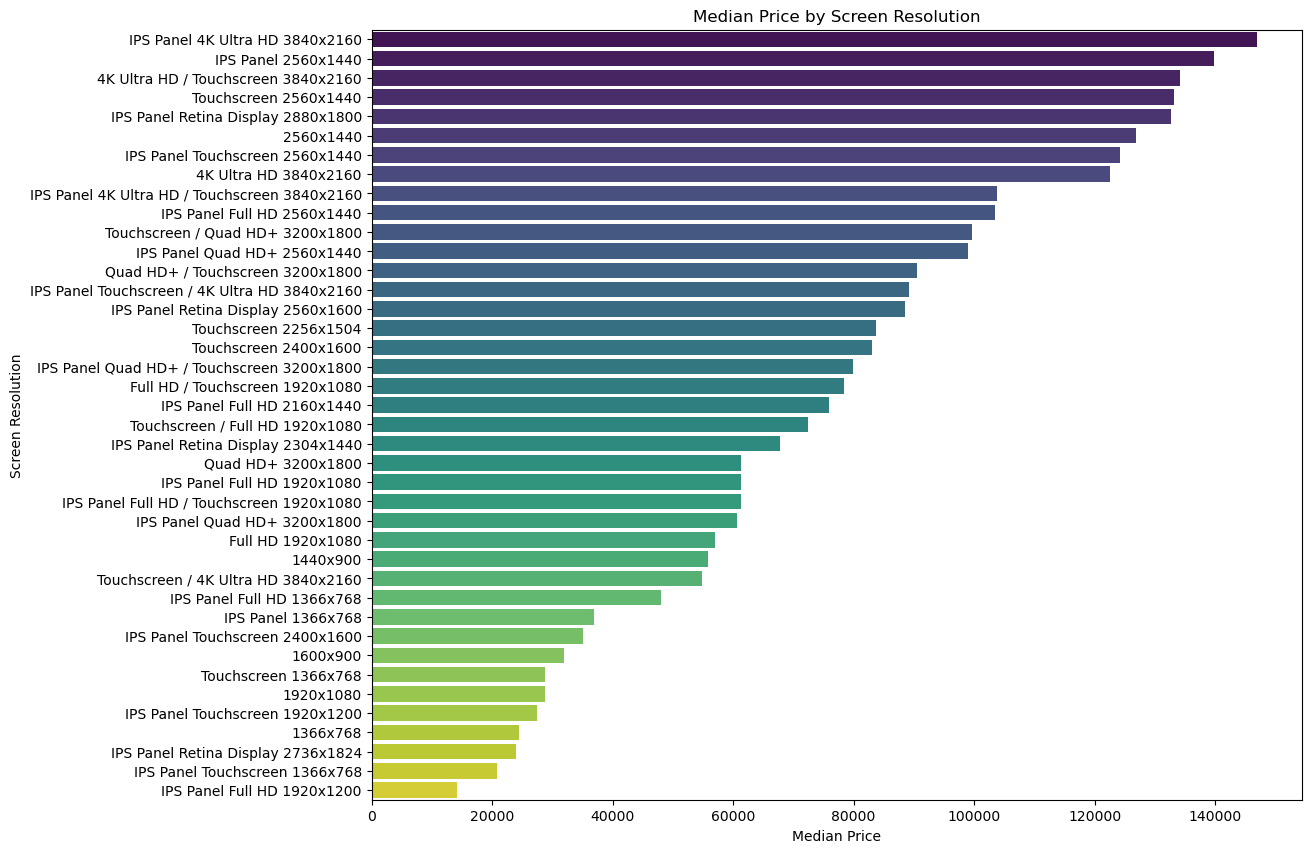

In [33]:
# Create a BAR CHART
median_price = df.groupby('ScreenResolution')['Price'].median().reset_index()
median_price = median_price.sort_values(by='Price', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x='Price', y='ScreenResolution', data=median_price, palette='viridis')
plt.title('Median Price by Screen Resolution')
plt.xlabel('Median Price')
plt.ylabel('Screen Resolution')
plt.show()

In [132]:
# Beispiel für die Kategorisierung von Speichergrößen
def categorize_memory(memory):
    if '8GB' in memory:
        return '8GB'
    elif '16GB' in memory:
        return '16GB'
    elif '32GB' in memory:
        return '32GB'
    elif '4GB' in memory:
        return '4GB'
    else:
        return 'Other'

df['MemoryCategory'] = df['Memory'].apply(categorize_memory)

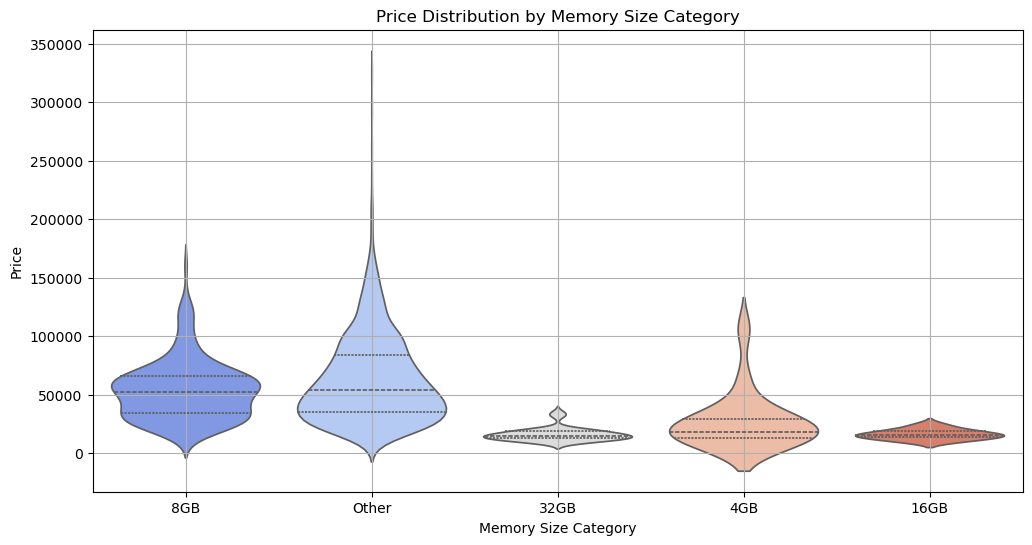

In [133]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='MemoryCategory', y='Price', data=df, palette='coolwarm', inner='quartile')

# Diagramm beschriften
plt.title('Price Distribution by Memory Size Category')
plt.xlabel('Memory Size Category')
plt.ylabel('Price')
plt.grid()

# Diagramm anzeigen
plt.show()

**3D Visualization**

In [38]:
import plotly.express as px

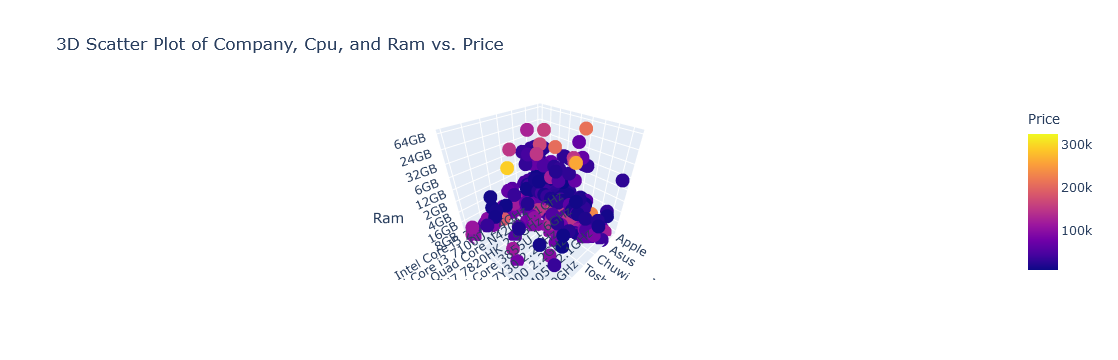

In [52]:
px.scatter_3d(df, x='Company', y='Cpu', z='Ram', color='Price',
                     title='3D Scatter Plot of Company, Cpu, and Ram vs. Price')

**Data Processing**

In [285]:
# Drop the column
df.drop(columns=['Unnamed: 0'], inplace=True)

In [286]:
# Convert the column with map 
df['Company'] = df['Company'].map({'Dell': 0, 'Lenovo': 1, 'HP': 2, 'Asus': 3, 'Acer': 4, 'MSI': 5, 'Toshiba': 6, 'Apple': 7,
                                   'Samsung': 8, 'Razer': 9, 'Mediacom': 10, 'Microsoft': 11, 'Xiaomi': 12, 'Vero': 13, 
                                   'Chuwi': 14, 'Google': 15, 'Fujitsu': 16, 'LG': 17, 'Huawei': 18})
df['TypeName'] = df['TypeName'].map({'Notebook': 0, 'Gaming': 1, 'Ultrabook': 2, '2 in 1 Convertible': 3, 'Workstation': 4, 'Netbook': 5})
df['ScreenResolution'] = df['ScreenResolution'].map({
    'Full HD 1920x1080': 0,
    '1366x768': 1,
    'IPS Panel Full HD 1920x1080': 2,
    'IPS Panel Full HD / Touchscreen 1920x1080': 3,
    'Full HD / Touchscreen 1920x1080': 4,
    '1600x900': 5,
    'Touchscreen 1366x768': 6,
    'Quad HD+ / Touchscreen 3200x1800': 7,
    'IPS Panel 4K Ultra HD 3840x2160': 8,
    'IPS Panel 4K Ultra HD / Touchscreen 3840x2160': 9,
    '4K Ultra HD / Touchscreen 3840x2160': 10,
    '4K Ultra HD 3840x2160': 11,
    'Touchscreen 2560x1440': 12,
    'IPS Panel 1366x768': 13,
    'IPS Panel Quad HD+ / Touchscreen 3200x1800': 14,
    'IPS Panel Retina Display 2560x1600': 15,
    'IPS Panel Retina Display 2304x1440': 16,
    'Touchscreen 2256x1504': 17,
    'IPS Panel Touchscreen 2560x1440': 18,
    'IPS Panel Retina Display 2880x1800': 19,
    'IPS Panel Touchscreen 1920x1200': 20,
    '1440x900': 21,
    'IPS Panel 2560x1440': 22,
    'IPS Panel Quad HD+ 2560x1440': 23,
    'Quad HD+ 3200x1800': 24,
    '1920x1080': 25,
    'Touchscreen 2400x1600': 26,
    '2560x1440': 27,
    'IPS Panel Touchscreen 1366x768': 28,
    'IPS Panel Touchscreen / 4K Ultra HD 3840x2160': 29,
    'IPS Panel Full HD 2160x1440': 30,
    'IPS Panel Quad HD+ 3200x1800': 31,
    'IPS Panel Retina Display 2736x1824': 32,
    'IPS Panel Full HD 1920x1200': 33,
    'IPS Panel Full HD 2560x1440': 34,
    'IPS Panel Full HD 1366x768': 35,
    'Touchscreen / Full HD 1920x1080': 36,
    'Touchscreen / Quad HD+ 3200x1800': 37,
    'Touchscreen / 4K Ultra HD 3840x2160': 38,
    'IPS Panel Touchscreen 2400x1600': 39})
df['Ram'] = df['Ram'].map({'2GB': 0, '4GB': 1, '6GB': 2, '8GB': 3, '12GB': 4, '16GB': 5, '24GB': 6, '32GB': 7, '64GB': 8})
df['OpSys'] = df['OpSys'].map({'Windows 10': 0,'No OS': 1,'Linux': 2,'Windows 7': 3,'Chrome OS': 4,'macOS': 5,'Mac OS X': 6,'Windows 10 S': 7,'Android': 8})                                     

In [287]:
# Categorization function
def categorize_cpu(cpu):
    if 'i3' in cpu:
        return 'Intel Core i3'
    elif 'i5' in cpu:
        return 'Intel Core i5'
    elif 'i7' in cpu:
        return 'Intel Core i7'
    elif 'Celeron' in cpu:
        return 'Celeron'
    elif 'Pentium' in cpu:
        return 'Pentium'
    elif 'AMD' in cpu:
        return 'AMD'
    else:
        return 'Other'
        
# Apply the categorization function to the 'Cpu' column
df['Cpu'] = df['Cpu'].apply(categorize_cpu)

# Mapping to numerical values
df['Cpu'] = df['Cpu'].map({'Intel Core i3': 0, 'Intel Core i5': 1, 'Intel Core i7': 2, 'Celeron': 3, 'Pentium': 4, 'AMD': 5, 'Other': 6})

In [288]:
df['Memory'] = df['Memory'].str.replace(r'[a-zA-Z+ \-]', '', regex=True).astype(float)

In [289]:
# Categorization function
def categorize(gpu):
    if 'Nvidia' in gpu:
        return 'Nvidia'
    elif 'AMD' in gpu:
        return 'AMD'
    elif 'Intel' in gpu:
        return 'Intel'
    else:
        return 'Other'

# Apply the categorization function to the column
df['Gpu'] = df['Gpu'].apply(categorize)

# Mapping GPU types to numerical values
df['Gpu'] = df['Gpu'].map({'Nvidia': 0, 'AMD': 1, 'Intel': 2, 'Other': 3})

In [290]:
def categorize(weight):
    try:
        weight_value = float(weight[:-2])  # Entferne 'kg' und konvertiere in float
        if weight_value < 1.0:
            return 'Light'
        elif 1.0 <= weight_value < 2.0:
            return 'Medium'
        elif 2.0 <= weight_value < 3.0:
            return 'Heavy'
        else:
            return 'Extra Heavy'
    except ValueError:
        return None  # Rückgabe von None für ungültige Werte / # Return None for invalid values

# Apply the categorization function to the 'Weight' column
df['Weight'] = df['Weight'].apply(categorize)

# Mapping weight categories to numeric values
df['Weight'] = df['Weight'].map({'Light': 0, 'Medium': 1, 'Heavy': 2, 'Extra Heavy': 3})

In [291]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,7,2,13.3,15,1,3,128.0,2,5,1,71378.6832
1,7,2,13.3,21,1,3,128.0,2,5,1,47895.5232


In [310]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   int64  
 1   TypeName          1303 non-null   int64  
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   int64  
 4   Cpu               1303 non-null   int64  
 5   Ram               1303 non-null   int64  
 6   Memory            1303 non-null   float64
 7   Gpu               1303 non-null   int64  
 8   OpSys             1303 non-null   int64  
 9   Weight            1303 non-null   int64  
 10  Price             1303 non-null   float64
dtypes: float64(3), int64(8)
memory usage: 112.1 KB


In [292]:
df.corr(numeric_only=True)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
Company,1.000000,0.027124,-0.108789,0.219431,0.147365,0.012762,-0.013084,0.025846,0.212523,-0.126185,0.056740
TypeName,0.027124,1.000000,-0.463868,0.293977,0.143333,0.215749,0.036693,0.094284,0.156224,-0.289614,0.368501
Inches,-0.108789,-0.463868,1.000000,-0.304960,-0.107448,0.209205,0.031083,-0.582477,-0.250232,0.777510,0.068197
ScreenResolution,0.219431,0.293977,-0.304960,1.000000,0.124527,0.135239,-0.018703,0.153967,0.288142,-0.217157,0.208904
Cpu,0.147365,0.143333,-0.107448,0.124527,1.000000,0.000311,-0.002329,-0.031691,0.100700,-0.078567,-0.001507
Ram,0.012762,0.215749,0.209205,0.135239,0.000311,1.000000,0.071500,-0.414242,-0.115751,0.216783,0.748465
Memory,-0.013084,0.036693,0.031083,-0.018703,-0.002329,0.071500,1.000000,0.004048,-0.029164,-0.010943,0.045865
Gpu,0.025846,0.094284,-0.582477,0.153967,-0.031691,-0.414242,0.004048,1.000000,0.155495,-0.565248,-0.282968
OpSys,0.212523,0.156224,-0.250232,0.288142,0.100700,-0.115751,-0.029164,0.155495,1.000000,-0.182578,-0.034032
Weight,-0.126185,-0.289614,0.777510,-0.217157,-0.078567,0.216783,-0.010943,-0.565248,-0.182578,1.000000,0.105390


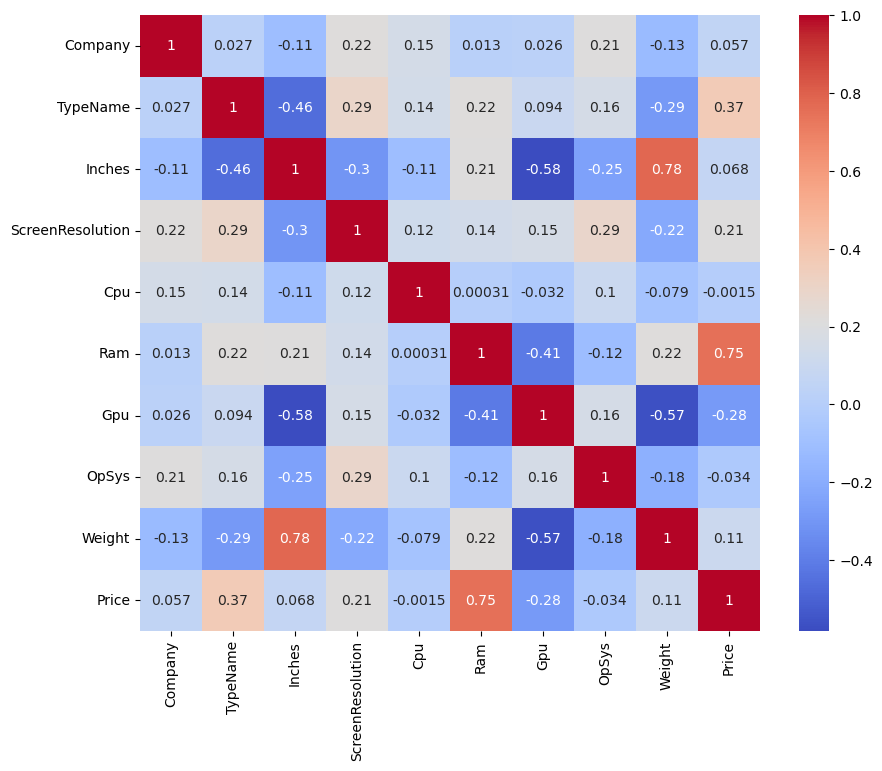

In [242]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm');

**Feature Engineering**

In [293]:
x=df.drop(['Price'],axis=1)
y=df[['Price']]

In [294]:
from sklearn.model_selection import train_test_split

In [295]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [296]:
print(x_test)

      Company  TypeName  Inches  ScreenResolution  Cpu  Ram    Memory  Gpu  \
479         6         0    13.3                 2    1    3     256.0    2   
1022        2         0    13.3                 2    1    3     256.0    2   
298         1         0    15.6                 0    5    2       1.0    1   
1265        1         0    15.6                 2    2    3       1.0    0   
774         2         2    12.5                 1    1    1     256.0    2   
115         2         3    13.3                 3    1    3     256.0    2   
582         2         0    13.3                 0    0    1     128.0    2   
527         1         0    15.6                 1    0    3       2.0    0   
380         2         1    17.3                 2    2    3    1281.0    0   
101         2         0    15.6                 0    5    1     500.0    1   
420         1         3    15.6                 9    2    5     512.0    0   
712         0         0    15.6                 0    1    3     

**Modelling**

In [297]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [298]:
model=lr.fit(x_train,y_train)

In [299]:
tahmin=model.predict(x_test)

In [300]:
from sklearn.metrics import r2_score, mean_squared_error

In [301]:
mean_squared_error(y_test,tahmin)**.5 

25454.462422779798

In [302]:
r2_score(y_test,tahmin)

0.5506357340930268

In [303]:
lr.coef_

array([[ 4.01735291e+02,  7.15786181e+03,  1.12277914e+03,
         4.13872380e+02, -1.58521505e+03,  1.70830357e+04,
         4.71464988e-03, -4.75951727e+02, -9.75977509e+01,
         2.48581011e+02]])

In [304]:
feature_importance=pd.DataFrame({'Feature':x_train.columns,'Coefs':lr.coef_[0]})

In [305]:
feature_importance=feature_importance.sort_values(by='Coefs',ascending=False)

In [306]:
feature_importance

,Feature,Coefs
5,Ram,17083.035737
1,TypeName,7157.861805
2,Inches,1122.779137
3,ScreenResolution,413.872380
0,Company,401.735291
9,Weight,248.581011
6,Memory,0.004715
8,OpSys,-97.597751
7,Gpu,-475.951727
4,Cpu,-1585.215051


In [ ]:
# I also tried the Algo Test 

In [278]:
#!pip install xgboost

In [307]:
from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
#pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler


def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        sgd=SGDRegressor()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        rkn=RadiusNeighborsRegressor(radius=1.0)
        ada=AdaBoostRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
        svr=SVR()
        mlp_regressor = MLPRegressor()

       
        
        algos=[L,R,Lass,E,sgd,ETR,GBR,ada,kn,dt,xgb,svr,mlp_regressor]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','SGD','Extra Tree','Gradient Boosting',
                    'KNeighborsRegressor','AdaBoost','Decision Tree','XGBRegressor','SVR','mlp_regressor']
        
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.20,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [308]:
algo_test(x,y)

,R_Squared,RMSE,MAE
Gradient Boosting,7.801275e-01,1.780533e+04,1.116972e+04
XGBRegressor,7.295905e-01,1.974584e+04,1.106337e+04
Decision Tree,6.348535e-01,2.294554e+04,1.341558e+04
KNeighborsRegressor,6.348364e-01,2.294608e+04,1.827505e+04
Extra Tree,6.122583e-01,2.364482e+04,1.357556e+04
Lasso,5.506408e-01,2.545432e+04,1.787529e+04
Ridge,5.506387e-01,2.545438e+04,1.787449e+04
Linear,5.506357e-01,2.545446e+04,1.787559e+04
ElasticNet,5.344042e-01,2.591011e+04,1.794430e+04
AdaBoost,5.285567e-01,2.607230e+04,1.399407e+04


In [ ]:
# Sonuc: Feature Engineering r² 0.55% ve Algo Test Gradient Boosting R² 7.801275e-01 ile tamamlandi. Basarili degil sanki ALgo testi degerlendiremedim 
# Data'yi islerken sanki rakamlar daha farklimi olmaliydi bilemedim

<img src='https://4.bp.blogspot.com/-iwnG54Bznlw/UKa8DUNe9TI/AAAAAAAAAh0/oYntQjZyWyw/w1200-h630-p-k-no-nu/IMG_0195[1].PNG' width=800>